# Rule-Based Regime Segmentation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

### Load data using relative path
# data_path = r'C:\Users\jacob\Documents\GitHub\COMP0047-Data-Science-Project\notebooks\data\master_data.csv'
data_path = Path('../../../data/master_data.csv')
df = pd.read_csv(data_path)

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

price_col = 'GSPC'
ret_col = 'Return'

print(f"Data loaded. Shape: {df.shape}")
df.head()

Data loaded. Shape: (6164, 27)


,Date,GSPC,VIX,SPY Volume,Gold,Oil,GDP,Core_Inflation,Unemployment,M2,...,MACD_Signal,MACD_Hist,GDP_YoY,Core_Inflation_YoY,M2_YoY,Peak,Drawdown,VIX_Change,VIX_Change_5d,Regime
0,2001-08-30,1129.030029,25.410000,17692600,275.399994,26.549999,14214.516,76.553,4.9,5243.8,...,-11.129843,-2.983369,0.004892,0.020421,0.088038,1520.77002,-0.257593,2.379999,3.180000,NaN
1,2001-08-31,1133.579956,24.920000,15985400,274.399994,27.200001,14214.516,76.553,4.9,5243.8,...,-12.009273,-3.517721,0.004892,0.020421,0.088038,1520.77002,-0.254601,-0.490000,5.210001,NaN
2,2001-09-04,1132.939941,25.850000,24473400,271.600006,26.930000,14214.516,76.118,5.0,5355.1,...,-12.909172,-3.599596,0.004892,0.012167,0.102962,1520.77002,-0.255022,0.930000,5.290001,NaN
3,2001-09-05,1131.739990,26.350000,21477100,272.000000,26.950001,14214.516,76.118,5.0,5355.1,...,-13.764448,-3.421104,0.004892,0.012167,0.102962,1520.77002,-0.255811,0.500000,4.350000,NaN
4,2001-09-06,1106.400024,28.610001,21653000,273.000000,27.580000,14214.516,76.118,5.0,5355.1,...,-14.919833,-4.621539,0.004892,0.012167,0.102962,1520.77002,-0.272474,2.260000,5.580000,NaN


## Rule-Based Logic

We classify market regimes using a strategy based on Simple Moving Averages (SMA):

| Indicator | Definition |
|-----------|------------|
| **SMA 50** | 50-day Simple Moving Average of the S&P 500 price |
| **SMA 200** | 200-day Simple Moving Average of the S&P 500 price |
| **Rolling Volatility** | 21-day rolling standard deviation of daily returns |

**Regime Rules:**
- **Bull**: SMA(50) > SMA(200) — the short-term trend is above the long-term trend
- **Bear**: SMA(50) ≤ SMA(200) — the short-term trend is below the long-term trend

For the initial 200 days where the 200-day SMA is unavailable, backfill with the first observed regime.

In [2]:
# Calculate Moving Averages for Rule-Based Logic
df['SMA_50'] = df[price_col].rolling(window=50).mean()
df['SMA_200'] = df[price_col].rolling(window=200).mean()
df['Roll_Vol_21d'] = df[ret_col].rolling(window=21).std()

# Drop NaNs from the longest rolling window (200 days) to ensure clean logic
df_clean = df.dropna(subset=['SMA_200']).copy().reset_index(drop=True)
print(f"Cleaned data shape (after dropping 200d NaNs): {df_clean.shape}")

Cleaned data shape (after dropping 200d NaNs): (5965, 30)


In [3]:
conditions = [
    (df_clean['SMA_50'] > df_clean['SMA_200']),
    (df_clean['SMA_50'] <= df_clean['SMA_200'])
]
choices = ['bull', 'bear']

# Initialize as object to avoid dtype issues
df_clean['regime'] = pd.Series(dtype='object')
df_clean['regime'] = np.select(conditions, choices, default='unknown')

# Merge back to original dataframe
# We drop the old 'Regime' or 'regime' columns if they exist to avoid conflicts
if 'Regime' in df.columns:
    df = df.drop(columns=['Regime'])

df = df.merge(df_clean[['Date', 'regime']], on='Date', how='left')

# For the first 200 days (where SMA_200 is NaN), we can backfill with the first known regime
first_regime = df_clean['regime'].iloc[0]
df['regime'] = df['regime'].fillna(first_regime)

print("Rule-based regime mapping complete.")
print("\nRegime Counts:")
print(df['regime'].value_counts())
print("\nRegime Proportions:")
print(df['regime'].value_counts(normalize=True).round(3))

Rule-based regime mapping complete.

Regime Counts:
regime
bull    4499
bear    1665
Name: count, dtype: int64

Regime Proportions:
regime
bull    0.73
bear    0.27
Name: proportion, dtype: float64


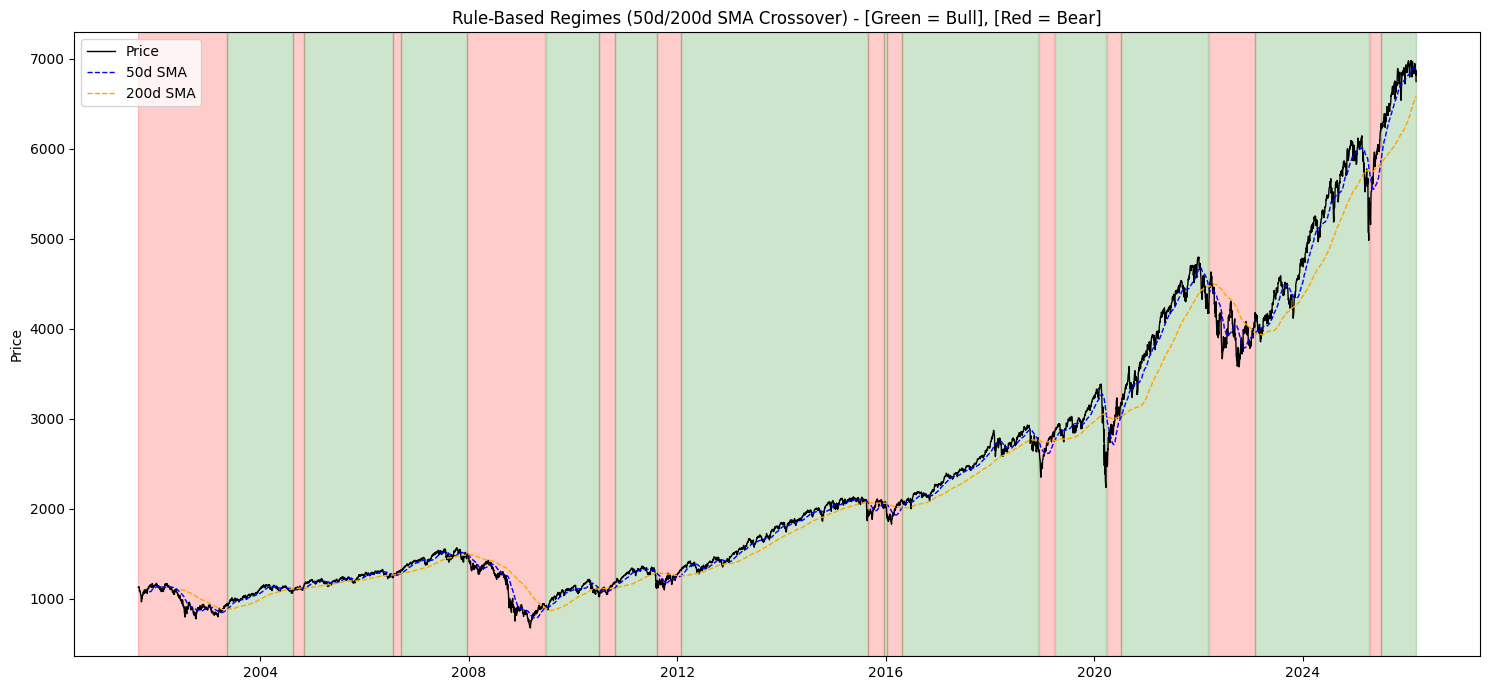

In [4]:
fig, ax1 = plt.subplots(figsize=(15, 7))

ax1.plot(df['Date'], df[price_col], color='black', linewidth=1, label='Price')
ax1.plot(df['Date'], df['SMA_50'], color='blue', linewidth=1, linestyle='--', label='50d SMA')
ax1.plot(df['Date'], df['SMA_200'], color='orange', linewidth=1, linestyle='--', label='200d SMA')
ax1.set_title('Rule-Based Regimes (50d/200d SMA Crossover) - [Green = Bull], [Red = Bear]')
ax1.set_ylabel('Price')
ax1.legend(loc='upper left')

# Add shading
df['regime_change'] = (df['regime'] != df['regime'].shift(1)).cumsum()
for _, group in df.groupby('regime_change'):
    start_date = group['Date'].iloc[0]
    end_date = group['Date'].iloc[-1]
    regime = group['regime'].iloc[0]
    color = 'green' if regime == 'bull' else 'red'
    ax1.axvspan(start_date, end_date, color=color, alpha=0.2)

plt.tight_layout()
plt.show()
df = df.drop(columns=['regime_change'])

In [5]:
missing_regimes = df['regime'].isna().sum()
assert missing_regimes == 0, f"Error: Found {missing_regimes} missing values in 'regime' column!"
print("Validation passed: No missing values in 'regime' column.")

# write df to .csv
output_csv = r'../../../data/rule_based_labeled_dataset.csv'
df.to_csv(output_csv, index=False)
print(f"Dataset saved to {output_csv}")

Validation passed: No missing values in 'regime' column.
Dataset saved to ../../../data/rule_based_labeled_dataset.csv
